In [4]:
import pandas as pd
from sqlalchemy import create_engine

user = "gsus2022_SQLLogin_1"
password = "k1g7yn8m87"
host = "tareasenati.mssql.somee.com"
database = "tareasenati"

In [5]:
engine = create_engine(
    f"mssql+pyodbc://{user}:{password}@{host}/{database}?driver=SQL+Server"
)
sql = "select * from familia"
familia = pd.read_sql(sql, engine)
print(familia)

   idfamilia   nombre          descripcion
0          1  Bebidas         Todo bebidas
1          2  Lácteos         Todo lácteos
2          3  Escolar  Productos escolares


In [6]:
sql = "select * from categoria"
categoria = pd.read_sql(sql,engine)
print(categoria)

   idcategoria        nombre  idfamilia
0            1       Gaseosa          1
1            2  Agua mineral          1
2            3         Leche          2
3            4         Queso          2


In [7]:
vista_categorias = categoria.merge(familia, how="inner", on="idfamilia")
vista_categorias = vista_categorias.rename(columns={"nombre_x": "categoria", "nombre_y": "familia"})
print(vista_categorias)

   idcategoria     categoria  idfamilia  familia   descripcion
0            1       Gaseosa          1  Bebidas  Todo bebidas
1            2  Agua mineral          1  Bebidas  Todo bebidas
2            3         Leche          2  Lácteos  Todo lácteos
3            4         Queso          2  Lácteos  Todo lácteos


In [8]:
vista_resumen_categorias = vista_categorias[["categoria", "familia"]]
print(vista_resumen_categorias)

      categoria  familia
0       Gaseosa  Bebidas
1  Agua mineral  Bebidas
2         Leche  Lácteos
3         Queso  Lácteos


In [9]:
print(vista_resumen_categorias.groupby("familia")["categoria"].count())

familia
Bebidas    2
Lácteos    2
Name: categoria, dtype: int64


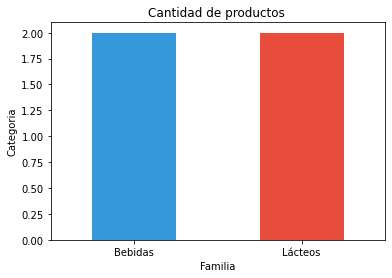

In [10]:
import matplotlib.pyplot as plt

conteo = vista_resumen_categorias.groupby("familia")["categoria"].count()

colores = ['#3498db', '#e74c3c']

ax = conteo.plot(kind='bar', color=colores, rot=0)

plt.title('Cantidad de productos ')
plt.xlabel('Familia')
plt.ylabel('Categoria')

plt.show()